# 🛒 Market Basket Analysis & Customer Segmentation

## ⏩ Problem Statement:
1. 🛒 Retail stores generate a large amount of transaction data every day.

2. 🔍 It is difficult to manually identify which products are frequently purchased together.

3. 📊 Customer purchasing behavior can vary significantly from one customer to another.

4. 👥 Without proper segmentation, it is difficult to understand different types of customers.

5. 🔗 Market Basket Analysis can help discover relationships between products using Apriori Association Rule Mining.

6. 📈 Customer Segmentation can group customers with similar purchasing behavior using K-Means Clustering.

7. 🎯 Therefore, this project aims to analyze transaction data to discover product associations and identify meaningful customer segments for better retail decision-making.



---

## ⏩ Objective :

1. 🛒 To analyze retail transaction data and understand customers' purchasing patterns.
2. 🧹 To clean and preprocess the retail dataset by handling missing values, cancelled transactions, and invalid records.
3. 📊 To perform **Exploratory Data Analysis (EDA)** to understand sales and customer behavior.
4. 🔗 To apply the **Apriori Algorithm** for discovering frequently purchased product combinations.
5. 📈 To generate **Association Rules** using measures such as Support, Confidence, and Lift.
6. 👥 To apply the **K-Means Clustering Algorithm** to segment customers according to their purchasing behavior.
7. 🎯 To identify meaningful customer groups that can support targeted marketing and business decisions.
8. 💡 To use the discovered product associations and customer segments for better product recommendations and retail strategies.

---

## ⏩ Dataset Information :

### 📁 Dataset File:

**`Online Retail.xlsx`**

| **Column Name**    | **Description**                                              |
| ------------------ | ------------------------------------------------------------ |
| 🧾 **InvoiceNo**   | Unique invoice number assigned to each customer transaction. |
| 🏷️ **StockCode**  | Unique code used to identify each product.                   |
| 📝 **Description** | Name or description of the product purchased.                |
| 🔢 **Quantity**    | Number of units of the product purchased in a transaction.   |
| 📅 **InvoiceDate** | Date and time when the transaction was made.                 |
| 💰 **UnitPrice**   | Price of one unit of the product.                            |
| 👤 **CustomerID**  | Unique identification number assigned to each customer.      |
| 🌍 **Country**     | Country where the customer is located.                       |

---

## ⏩ Dataset Usage in the Project :

| **Technique**                 | **Data Used**                                    | **Purpose**                                                  |
| ----------------------------- | ------------------------------------------------ | ------------------------------------------------------------ |
| 🛒 **Market Basket Analysis** | InvoiceNo, StockCode, Description, Quantity      | To identify products that are frequently purchased together. |
| 🔗 **Apriori Algorithm**      | Transaction-wise product information             | To generate frequent itemsets and association rules.         |
| 👥 **Customer Segmentation**  | CustomerID, transaction and purchase information | To understand different customer purchasing behaviors.       |
| 🤖 **K-Means Clustering**     | Customer-level purchasing features               | To divide customers into meaningful groups.                  |

---

## ⏩ Key Outputs :

### 🛒 Market Basket Analysis

* 🔗 **Frequent Itemsets** are identified using the Apriori algorithm.
* 📊 **Association Rules** are generated using Support, Confidence, and Lift.
* 💡 Product relationships can be used for recommendations and cross-selling.

### 👥 Customer Segmentation

* 🤖 Customers are grouped using the **K-Means Clustering Algorithm**.
* 📊 Each cluster represents customers with similar purchasing behavior.
* 🎯 The segments can help businesses design targeted marketing strategies.

---

### 🎯 Overall Goal :

**To discover useful product relationships and customer purchasing patterns from retail transaction data using Machine Learning and Data Mining techniques.**




###▶ Section A : Data Understanding/Collection

➡ 1. Install Libraries

In [5]:
# Import the warnings module to manage warnings.
import warnings
# Filter out warnings to keep the output clean.
warnings.filterwarnings('ignore')

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
# Install necessary libraries: 'mlxtend' for market basket analysis and 'openpyxl' to read Excel files.
!pip install mlxtend openpyxl

 ➡ 2. Import Libraries

In [45]:
# Import pandas for data manipulation and analysis.
import pandas as pd
# Import numpy for numerical operations.
import numpy as np
# Import matplotlib.pyplot for plotting.
import matplotlib.pyplot as plt
# Import seaborn for advanced visualizations.
import seaborn as sns
import joblib

# Import StandardScaler for feature scaling (used in K-Means clustering).
from sklearn.preprocessing import StandardScaler
# Import KMeans for clustering.
from sklearn.cluster import KMeans
# Import silhouette_score for evaluating clustering performance.
from sklearn.metrics import silhouette_score

# Import require libraries for hierachical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Import apriori for frequent itemset generation (used in Market Basket Analysis).
from mlxtend.frequent_patterns import apriori
# Import association_rules for generating association rules from frequent itemsets.
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

➡ 3. Load Dataset

In [9]:
# Import pandas for data manipulation.
import pandas as pd

# Load the dataset from an Excel file named 'Online Retail.xlsx' into a pandas DataFrame.
df = pd.read_excel("Online Retail.xlsx")

# Print the shape of the DataFrame (number of rows, number of columns).
print("Dataset Shape:", df.shape)

# Display the first 5 rows of the DataFrame to get a quick overview of the data.
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


###▶ Section B: Data Cleaning
➡ 4. Data Cleaning

In [10]:
# Drop rows where 'CustomerID' is missing (NaN), as customer identification is crucial for analysis.
df = df.dropna(subset=['CustomerID'])

# Filter out rows where 'Quantity' is not positive, as non-positive quantities are usually returns or invalid entries.
df = df[df['Quantity'] > 0]

# Filter out rows where 'UnitPrice' is not positive, as non-positive prices are invalid.
df = df[df['UnitPrice'] > 0]

# Calculate 'TotalAmount' for each transaction by multiplying 'Quantity' and 'UnitPrice'.
df['TotalAmount'] = (
    df['Quantity'] * df['UnitPrice']
)

# Print the new shape of the DataFrame after cleaning.
print(df.shape)

(397884, 9)


In [11]:
# Display the column names of the DataFrame.
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [12]:
# Check for missing values (NaN) in each column and sum them up.
# This confirms that there are no missing values after the previous cleaning steps.
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


In [ ]:
df.duplicated().sum()


np.int64(5192)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Display a concise summary of the DataFrame, including data types, non-null values, and memory usage.
# This helps in understanding the data structure and identifying any potential issues with data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [16]:
# Generate descriptive statistics for numerical columns in the DataFrame.
# This provides insights into the central tendency, dispersion, and shape of the distribution of the data.
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


➡ Outlier Detection,IQR Method,Remove Outliers

In [17]:
# Step 1: Identify all numerical columns in the DataFrame for outlier detection.
# These columns typically have 'int64' or 'float64' data types.
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Print the list of identified numerical columns.
print(num_cols)

Index(['Quantity', 'UnitPrice', 'CustomerID', 'TotalAmount'], dtype='object')


In [18]:
# Step 2: Iterate through each numerical column to count the number of outliers using the IQR method.
for col in num_cols:

    # Calculate the first quartile (Q1).
    Q1 = df[col].quantile(0.25)
    # Calculate the third quartile (Q3).
    Q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR).
    IQR = Q3 - Q1

    # Calculate the lower bound for outlier detection.
    lower = Q1 - 1.5 * IQR
    # Calculate the upper bound for outlier detection.
    upper = Q3 + 1.5 * IQR

    # Identify outliers: values below the lower bound or above the upper bound.
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    # Print the column name and the count of outliers found in that column.
    print(f"{col}: {len(outliers)} outliers")

Quantity: 25616 outliers
UnitPrice: 34112 outliers
CustomerID: 0 outliers
TotalAmount: 31231 outliers


In [19]:
# Step 3: Handle outliers in numerical columns by clipping them to the calculated IQR bounds.
for col in num_cols:

    # Calculate the first quartile (Q1).
    Q1 = df[col].quantile(0.25)
    # Calculate the third quartile (Q3).
    Q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR).
    IQR = Q3 - Q1

    # Calculate the lower bound for outlier detection.
    lower = Q1 - 1.5 * IQR
    # Calculate the upper bound for outlier detection.
    upper = Q3 + 1.5 * IQR

    # Clip the values in the column: values below 'lower' become 'lower', and values above 'upper' become 'upper'.
    df[col] = df[col].clip(lower, upper)

In [20]:
# Step 4: Re-check for outliers in numerical columns after clipping to confirm they have been handled.
for col in num_cols:

    # Calculate the first quartile (Q1).
    Q1 = df[col].quantile(0.25)
    # Calculate the third quartile (Q3).
    Q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR).
    IQR = Q3 - Q1

    # Calculate the lower bound for outlier detection.
    lower = Q1 - 1.5 * IQR
    # Calculate the upper bound for outlier detection.
    upper = Q3 + 1.5 * IQR

    # Identify outliers: values below the lower bound or above the upper bound.
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    # Print the column name and the count of outliers found.
    # This should now show 0 outliers for all columns if clipping was effective.
    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
CustomerID: 0 outliers
TotalAmount: 0 outliers


Identify non-numeric values present in numeric attributes.

In [21]:
non_numeric=df.select_dtypes(include=['object']).columns
non_numeric

Index(['InvoiceNo', 'StockCode', 'Description', 'Country'], dtype='object')

Generate a cleaned version of the dataset.

In [22]:
cleaned_df = df.copy()
cleaned_df.to_csv('online_retail.csv', index=False)
display(cleaned_df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


###▶ Section C:Exploratory Data Analysis (EDA)

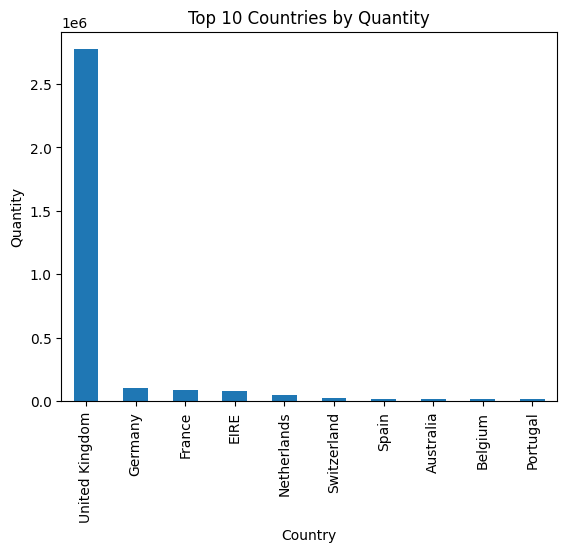

In [23]:
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Countries by Quantity')
plt.xlabel('Country')
plt.ylabel('Quantity')
plt.show()


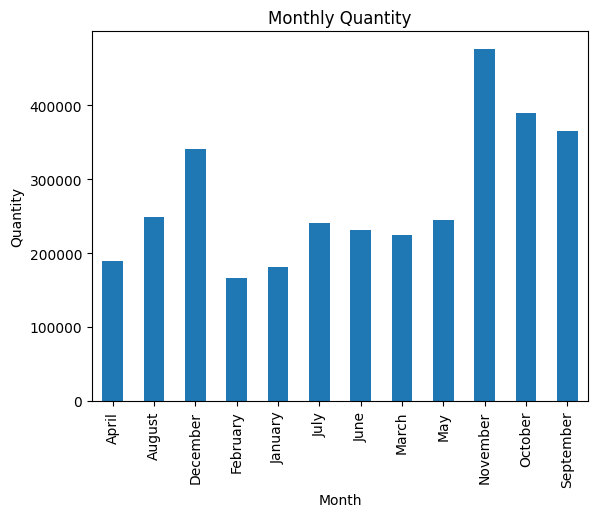

In [24]:
df['month'] = pd.to_datetime(df['InvoiceDate']).dt.month_name()
df.groupby('month')['Quantity'].sum().plot(kind='bar')
plt.title('Monthly Quantity')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.show()

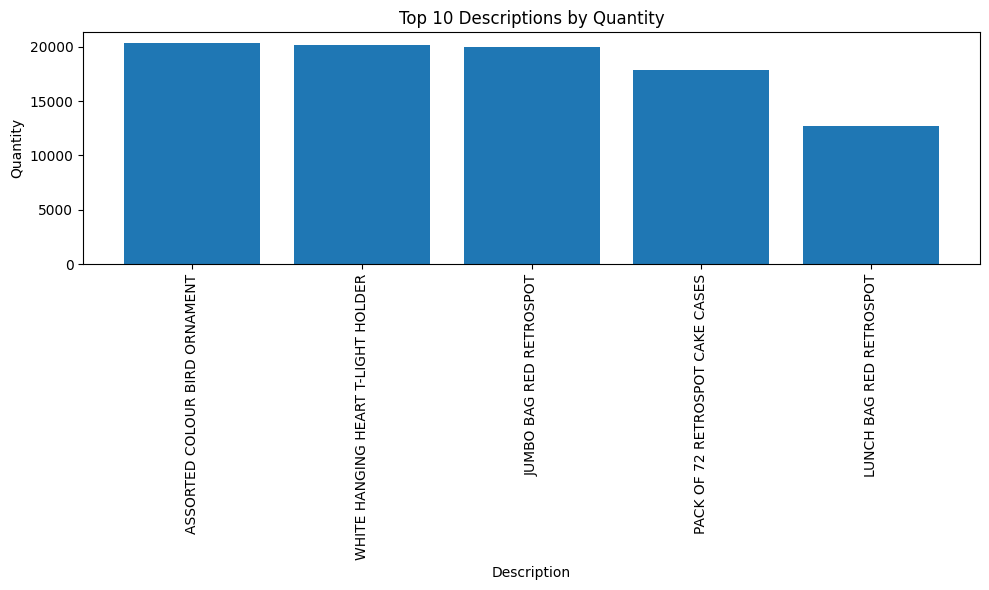

In [25]:
df['Description'] = df['Description'].astype(str)

top_descriptions = df.groupby('Description')['Quantity'].sum().nlargest(5)

plt.figure(figsize=(10, 6))
plt.bar(top_descriptions.index, top_descriptions.values)
plt.title('Top 10 Descriptions by Quantity')
plt.xlabel('Description')
plt.ylabel('Quantity')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Total Sales Amount Over Time

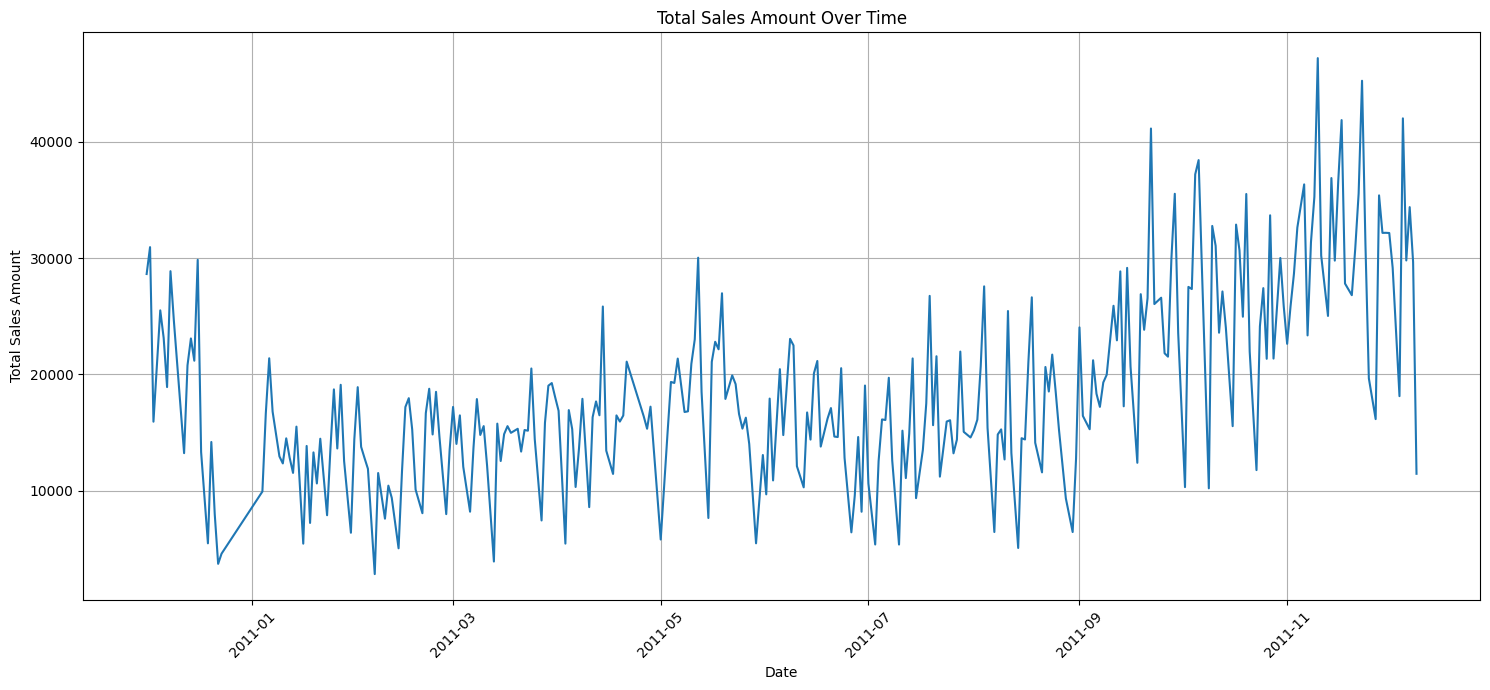

In [26]:
# Calculate daily total sales amount
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='InvoiceDate', y='TotalAmount', data=daily_sales)
plt.title('Total Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Distribution of Total Amount

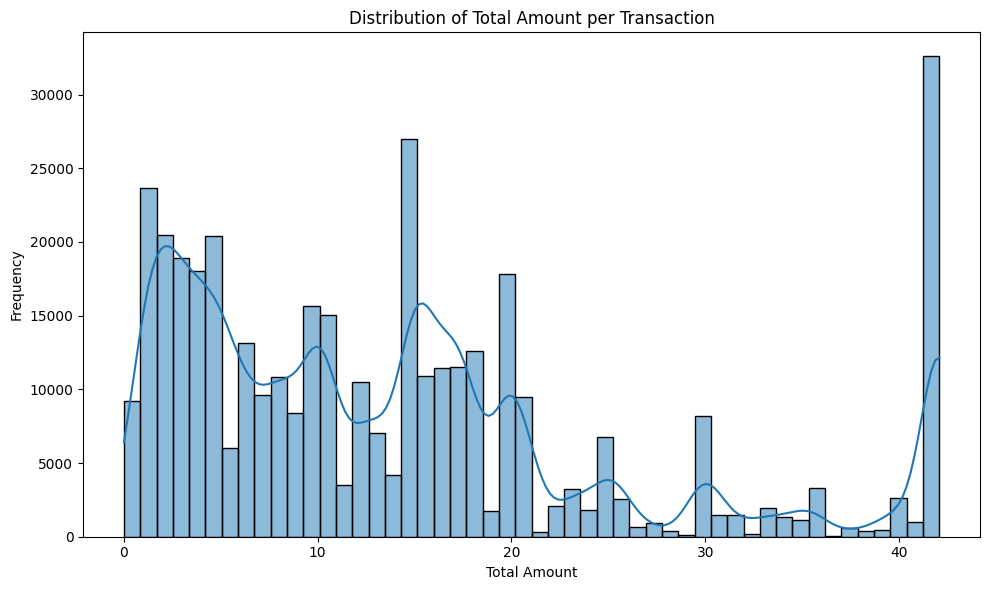

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalAmount'], bins=50, kde=True)
plt.title('Distribution of Total Amount per Transaction')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Next, let's implement hierarchical clustering using `AgglomerativeClustering` and visualize it with a dendrogram.

##⏩ PART C: HIERARCHICAL CLUSTERING

➡ **15. Hierarchical Clustering and Dendrogram**

➡ Scaled Customer Data

In [28]:
# Group the DataFrame by 'CustomerID' and aggregate 'Quantity' and 'TotalAmount'.
# This creates a new DataFrame 'customer' where each row represents a unique customer
# and their total quantity of items purchased and total amount spent.
customer = df.groupby('CustomerID').agg({
    'Quantity':'sum',
    'TotalAmount':'sum'
})

# Display the first few rows of the 'customer' DataFrame to inspect the aggregated data.
customer.head()

,Quantity,TotalAmount
CustomerID,,
12346.0,27,42.075
12347.0,2167,3763.670
12348.0,716,1106.540
12349.0,613,1439.875
12350.0,197,334.400


In [29]:
# Initialize a StandardScaler object. This scaler will standardize features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit the scaler to the 'customer' data and transform it.
# 'scaled_data' will contain the standardized 'Quantity' and 'TotalAmount' for each customer.
# This is important for K-Means clustering, which is sensitive to feature scales.
scaled_data = scaler.fit_transform(customer)

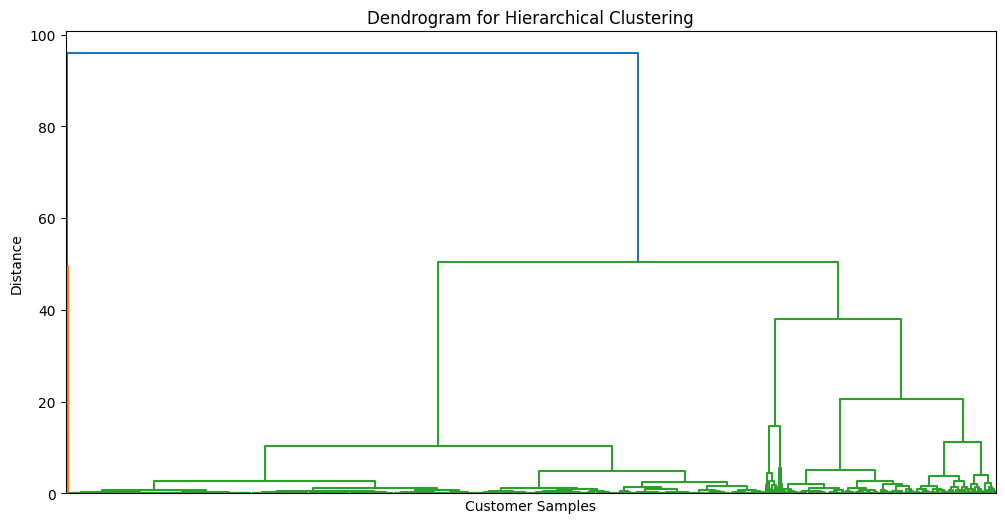

Hierarchical clustering performed with 4 clusters.
Cluster distribution:
Hierarchical_Cluster
2    3250
0    1075
3      11
1       2
Name: count, dtype: int64


In [31]:
# Perform hierarchical clustering using the 'ward' method
# The 'ward' method minimizes the variance of the clusters being merged.
linked_data = linkage(scaled_data, method='ward')

#plt.figure(figsize=(15, 10))
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linked_data,
           #orientation='top',
           #distance_sort='descending',
           #show_leaf_counts=True,
           ax=ax,
    no_labels=True,
    color_threshold=None)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customer Samples')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.show()

# Based on the dendrogram, let's determine the optimal number of clusters, for example, 4.
n_clusters_hierarchical = 4
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')
hierarchical_clusters = hierarchical_model.fit_predict(scaled_data)

customer['Hierarchical_Cluster'] = hierarchical_clusters

print(f"Hierarchical clustering performed with {n_clusters_hierarchical} clusters.")
print("Cluster distribution:")
print(customer['Hierarchical_Cluster'].value_counts())

➡ **16. Evaluate Hierarchical Clustering**

In [ ]:
# Calculate the Silhouette Score for hierarchical clustering
hierarchical_silhouette_score = silhouette_score(scaled_data, hierarchical_clusters)
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette_score}")

# Display summary of hierarchical clusters
print("\nHierarchical Cluster Summary (Mean Quantity and TotalAmount):")
print(customer.groupby('Hierarchical_Cluster')[['Quantity', 'TotalAmount']].mean())

Hierarchical Clustering Silhouette Score: 0.6620383659836476

Hierarchical Cluster Summary (Mean Quantity and TotalAmount):
                          Quantity   TotalAmount
Hierarchical_Cluster                            
0                      1928.331163   3304.120815
1                     55112.000000  95278.165000
2                       273.981538    484.253479
3                     20210.272727  33757.165000


### ➡ Cluster Distribution

Text(0.5, 1.0, 'Customers in Each Cluster')

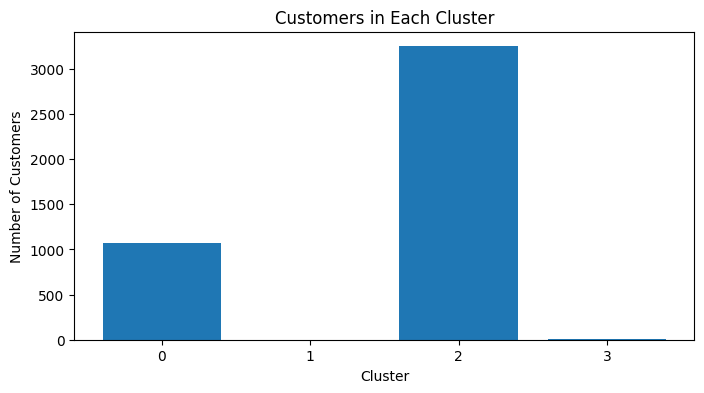

In [33]:
cluster_counts = (
    pd.Series(hierarchical_clusters)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")
ax.set_title("Customers in Each Cluster")

###▶ Section E : Model Selection
##⏩PART A: K-MEANS CLUSTERING
➡ 5. Customer Segmentation Data

➡ 7. Elbow Method

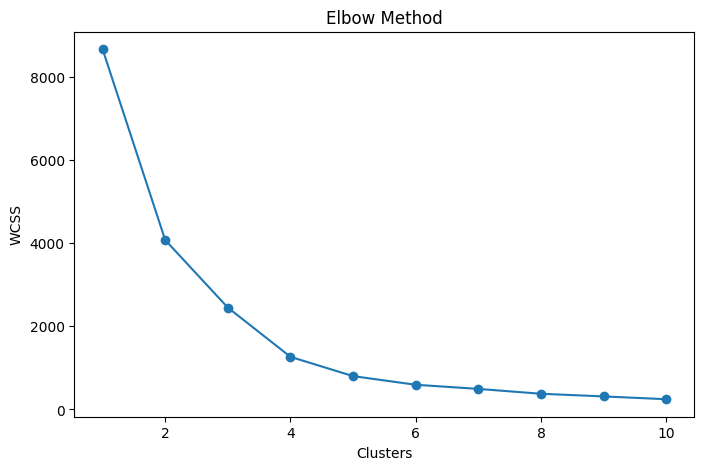

In [37]:
# Initialize an empty list to store the Within-Cluster Sum of Squares (WCSS).
wcss = []

# Loop from 1 to 10 (inclusive) to test different numbers of clusters.
for i in range(1,11):

    # Initialize a KMeans model with 'i' clusters and a fixed random state for reproducibility.
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    # Fit the KMeans model to the scaled customer data.
    kmeans.fit(scaled_data)

    # Append the WCSS (inertia) of the current model to the 'wcss' list.
    wcss.append(kmeans.inertia_)

# Create a new figure for the plot with a specified size.
plt.figure(figsize=(8,5))

# Plot the WCSS values against the number of clusters.
# 'marker='o'' adds circles to data points.
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

# Set the title of the plot.
plt.title("Elbow Method")
# Set the label for the x-axis.
plt.xlabel("Clusters")
# Set the label for the y-axis.
plt.ylabel("WCSS")

# Display the plot.
plt.show()

###▶ Section F : Model Training
➡ 8. K-Means Model

In [38]:
# Initialize the KMeans model with the optimal number of clusters (chosen as 4 based on the Elbow Method) and a random state for reproducibility.
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fit the KMeans model to the scaled customer data and predict the cluster assignments for each customer.
clusters = kmeans.fit_predict(
    scaled_data
)

# Add the 'Cluster' assignments as a new column to the 'customer' DataFrame.
customer['Cluster'] = clusters

###▶ Section G : Model Evaluation
➡ 9. Evaluation

In [39]:
# Calculate the Silhouette Score to evaluate the quality of the clustering.
# The Silhouette Score measures how similar an object is to its own cluster compared to other clusters.
score = silhouette_score(
    scaled_data,
    clusters
)

# Print the calculated Silhouette Score.
print("Silhouette Score:", score)

Silhouette Score: 0.7858130292711512


➡ 10. Cluster Summary

In [40]:
# Group the 'customer' DataFrame by the 'Cluster' column and calculate the mean of 'Quantity' and 'TotalAmount' for each cluster.
# This provides a summary of the characteristics of each customer segment.
print(customer.groupby('Cluster').mean())

             Quantity   TotalAmount  Hierarchical_Cluster
Cluster                                                  
0          444.655059    775.322061              1.640172
1         3318.309392   5671.691588              0.000000
2        20210.272727  33757.165000              3.000000
3        55112.000000  95278.165000              1.000000


##⏩ PART D: Model Comparison and Best Model Saving

➡ **17. Compare Clustering Algorithms**

In [41]:
# Ensure K-Means clustering is performed and 'Cluster' column is added to 'customer' DataFrame
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
customer['Cluster'] = clusters

# Compare the Silhouette Scores of K-Means and Hierarchical Clustering
kmeans_silhouette = silhouette_score(scaled_data, customer['Cluster'])
hierarchical_silhouette = silhouette_score(scaled_data, customer['Hierarchical_Cluster'])

print(f"K-Means Silhouette Score: {kmeans_silhouette}")
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette}")

if kmeans_silhouette > hierarchical_silhouette:
    print("\nK-Means clustering performed better based on Silhouette Score.")
    best_model_name = 'K-Means'
    best_model = kmeans # 'kmeans' object was defined earlier
    # Recalculate K-Means for clarity, though it's already done
    kmeans_best = KMeans(n_clusters=4, random_state=42)
    kmeans_best.fit(scaled_data)
else:
    print("\nHierarchical clustering performed better based on Silhouette Score.")
    best_model_name = 'Hierarchical Clustering'
    best_model = hierarchical_model # 'hierarchical_model' object was defined above

print(f"The best clustering model is: {best_model_name}")

K-Means Silhouette Score: 0.7858130292711512
Hierarchical Clustering Silhouette Score: 0.6620383659836476

K-Means clustering performed better based on Silhouette Score.
The best clustering model is: K-Means


➡ **18. Save the Best Model**

In [44]:
import joblib

# Define the filename for saving the best model
model_filename = f'{best_model_name.replace(" ", "_").lower()}_customer_segmentation_model.pkl'

# Save the best model using joblib
joblib.dump(best_model, model_filename)

print(f"Best model ('{best_model_name}') saved to '{model_filename}'")


Best model ('K-Means') saved to 'k-means_customer_segmentation_model.pkl'


##⏩ PART B: APRIORI ALGORITHM
➡ 11. Basket Matrix

In [46]:
# Group transactions by InvoiceNo and collect all items in each invoice into a list.
transactions = (
    df.groupby('InvoiceNo')['Description']
    .apply(list)
    .values.tolist()
)

# Initialize the TransactionEncoder.
te = TransactionEncoder()

# Fit and transform the transactions to a one-hot encoded array.
te_ary = te.fit(transactions).transform(transactions)

# Convert the one-hot encoded array into a DataFrame.
basket = pd.DataFrame(te_ary, columns=te.columns_)

➡ 12. Frequent Itemsets

In [47]:
# Apply the Apriori algorithm to find frequent itemsets in the 'basket' DataFrame.
# 'min_support' is set to 0.02, meaning itemsets that appear in at least 2% of transactions will be considered.
# 'use_colnames=True' ensures that item names (descriptions) are used instead of column indices.
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

# Print the top 10 frequent itemsets, sorted by their support in descending order.
print(
    frequent_items
    .sort_values(
        by='support',
        ascending=False
    )
    .head(10)
)

      support                              itemsets
192  0.106357  (WHITE HANGING HEART T-LIGHT HOLDER)
154  0.091895            (REGENCY CAKESTAND 3 TIER)
81   0.086337             (JUMBO BAG RED RETROSPOT)
124  0.074412                       (PARTY BUNTING)
11   0.074196       (ASSORTED COLOUR BIRD ORNAMENT)
102  0.069501             (LUNCH BAG RED RETROSPOT)
166  0.061839   (SET OF 3 CAKE TINS PANTRY DESIGN )
139  0.059303                             (POSTAGE)
95   0.056767             (LUNCH BAG  BLACK SKULL.)
116  0.055526     (PACK OF 72 RETROSPOT CAKE CASES)


➡ 13. Association Rules

In [49]:
# Generate association rules from the 'frequent_items' using the 'association_rules' function.
# 'metric='confidence'' specifies that confidence will be used to measure the strength of the rules.
# 'min_threshold=0.30' means only rules with a confidence of at least 30% will be generated.
rules = association_rules(
    frequent_items,
    metric='confidence',
    min_threshold=0.30
)

# Sort the generated rules by 'lift' in descending order.
# Lift indicates how much more likely item Y is to be bought when item X is bought, relative to its baseline probability.
rules = rules.sort_values(
    by='lift',
    ascending=False
)

# Display the top 10 association rules, showing 'antecedents', 'consequents', 'support', 'confidence', and 'lift'.
rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
67,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.021045,0.701439,24.027846
62,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.021045,0.720887,24.027846
64,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.021045,0.894495,23.989564
65,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.021045,0.564399,23.989564
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024822,0.827338,22.188466
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024822,0.665702,22.188466
66,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.021045,0.498084,20.066300
63,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.021045,0.847826,20.066300
57,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.023527,0.556833,18.559754
56,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.023527,0.784173,18.559754


➡ 14. Final Results

In [50]:
# Print a separator line for better readability.
print("="*50)

# Print the K-MEANS CLUSTERING section header.
print("K-MEANS RESULT")
# Print the calculated Silhouette Score, which evaluates the quality of the clustering.
print("Silhouette Score =", score)

# Print another separator line.
print("="*50)

# Print the TOP ASSOCIATION RULES section header.
print("TOP ASSOCIATION RULES")

# Display the top 10 association rules, selected by 'lift' in the previous step.
# The displayed columns are 'antecedents', 'consequents', 'confidence', and 'lift'.
display(
    rules[
        [
            'antecedents',
            'consequents',
            'confidence',
            'lift'
        ]
    ].head(10)
)

K-MEANS RESULT
Silhouette Score = 0.7858130292711512
TOP ASSOCIATION RULES


,antecedents,consequents,confidence,lift
67,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.701439,24.027846
62,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.720887,24.027846
64,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.894495,23.989564
65,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.564399,23.989564
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.827338,22.188466
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.665702,22.188466
66,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.498084,20.066300
63,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.847826,20.066300
57,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.556833,18.559754
56,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.784173,18.559754


In [51]:
# Save frequent itemsets
joblib.dump(frequent_items, "frequent_items.pkl")

# Save association rules
joblib.dump(rules, "association_rules.pkl")

# Save TransactionEncoder
joblib.dump(te, "transaction_encoder.pkl")

print("Files saved successfully!")

Files saved successfully!
